# Human Face Detection and Masking | Aadhaar Number Masking 

Using PDF2IMAGE to extract PDF pages and converted them into a image

In [17]:
from pdf2image import convert_from_path
poppler_path = r"C:\poppler\poppler-25.12.0\Library\bin"

pages_1 = convert_from_path(r"D:\Arya_User\Masking_Project\test_set.pdf", poppler_path=poppler_path)

Identify Human Face with YOLO Face Recognization 

In [29]:
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO((r"D:\Arya_User\Masking_Project\yolov8m-face.pt"))

def detect_and_mask_faces_yolo(pages_1):

    processed_images = []

    for i, page in enumerate(pages_1):

        img = cv2.cvtColor(np.array(page), cv2.COLOR_RGB2BGR)

        results = model(img)

        faces = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                faces.append((x1, y1, x2-x1, y2-y1))

        print(f"Page {i+1}: {len(faces)} faces detected")

        # ---------- MASKING ----------
        for (x, y, w, h) in faces:

            pad_w = int(0.085 * w)
            pad_h = int(0.085 * h)

            x1 = max(0, x - pad_w)
            y1 = max(0, y - pad_h)
            x2 = min(img.shape[1], x + w + pad_w)
            y2 = min(img.shape[0], y + h + pad_h)

            face = img[y1:y2, x1:x2]

            if face.size == 0:
                continue

            # Clean blur (BEST)
            blurred = cv2.GaussianBlur(face, (99, 99), 40)

            img[y1:y2, x1:x2] = blurred

        # ADD THIS LINE: Convert back to RGB for Pillow/Matplotlib compatibility
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        processed_images.append(img_rgb)

    return processed_images

processed_images = detect_and_mask_faces_yolo(pages_1)


0: 960x704 (no detections), 641.2ms
Speed: 7.3ms preprocess, 641.2ms inference, 0.9ms postprocess per image at shape (1, 3, 960, 704)
Page 1: 0 faces detected

0: 960x704 3 faces, 648.9ms
Speed: 9.2ms preprocess, 648.9ms inference, 1.7ms postprocess per image at shape (1, 3, 960, 704)
Page 2: 3 faces detected

0: 960x704 3 faces, 653.1ms
Speed: 8.9ms preprocess, 653.1ms inference, 0.9ms postprocess per image at shape (1, 3, 960, 704)
Page 3: 3 faces detected

0: 960x704 4 faces, 591.3ms
Speed: 6.3ms preprocess, 591.3ms inference, 1.0ms postprocess per image at shape (1, 3, 960, 704)
Page 4: 4 faces detected

0: 960x704 1 face, 632.2ms
Speed: 6.1ms preprocess, 632.2ms inference, 1.2ms postprocess per image at shape (1, 3, 960, 704)
Page 5: 1 faces detected

0: 960x704 3 faces, 921.2ms
Speed: 7.8ms preprocess, 921.2ms inference, 0.9ms postprocess per image at shape (1, 3, 960, 704)
Page 6: 3 faces detected

0: 960x704 (no detections), 751.5ms
Speed: 11.0ms preprocess, 751.5ms inference,

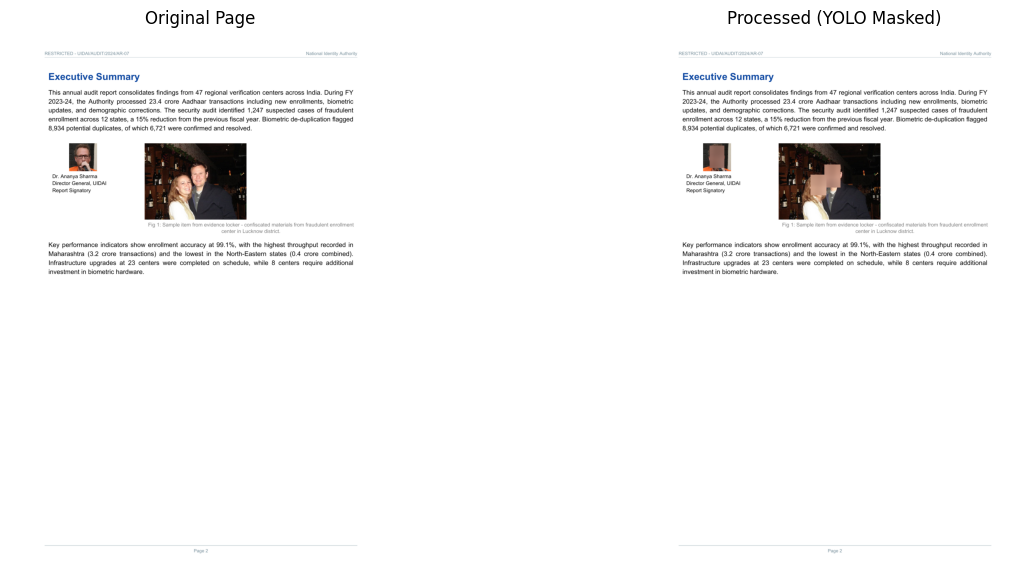

In [30]:
import matplotlib.pyplot as plt

page_index = 1 # Let's check Page 2 (3 faces detected)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Original
ax[0].imshow(pages_1[page_index])
ax[0].set_title("Original Page")
ax[0].axis('off')

# Processed (Masked)
ax[1].imshow(processed_images[page_index])
ax[1].set_title("Processed (YOLO Masked)")
ax[1].axis('off')

plt.show()

In [31]:
import pytesseract
import cv2
import re

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

def mask_aadhaar(img):

    # Improve OCR accuracy (keep simple)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]

    data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

    words = [w.strip() for w in data['text']]
    n = len(words)

    for i in range(n):

        collected = ""
        indices = []

        # 🔥 Flexible grouping (instead of fixed 3 words)
        for j in range(i, min(i + 3, n)):

            word_j = words[j].strip()

            # ❌ Skip words that contain alphabets
            if re.search(r'[A-Za-z]', word_j):
                continue

            clean = re.sub(r'[A-Za-z\s]', '', word_j)
            digits = re.sub(r'\D', '', clean)

            if digits:
                collected += digits
                indices.append(j)

            # Stop once we reach 12 digits
            if len(collected) >= 12:
                break

        # ---------- CASE 1: Any 12-digit (with/without spaces) ----------
        if len(collected) == 12:

            x1 = min(data['left'][k] for k in indices)
            y1 = min(data['top'][k] for k in indices)

            x2 = max(
                data['left'][k] + data['width'][k]
                for k in indices
            )

            y2 = max(
                data['top'][k] + data['height'][k]
                for k in indices
            )

            cv2.rectangle(img, (x1-3, y1-3), (x2+3, y2+3), (0, 0, 0), -1)

        # ---------- CASE 2: Single 12-digit ----------
        word = words[i]
        if re.fullmatch(r"\d{12}", word):

            x = data['left'][i]
            y = data['top'][i]
            w = data['width'][i]
            h = data['height'][i]

            cv2.rectangle(img, (x-3, y-3), (x+w+3, y+h+3), (0, 0, 0), -1)

    return img

In [32]:
from PIL import Image
import numpy as np
import cv2

processed_pages = []

for i, page in enumerate(processed_images):

    # Convert PIL → OpenCV
    img = cv2.cvtColor(np.array(page), cv2.COLOR_RGB2BGR)

    # Apply Aadhaar masking
    img = mask_aadhaar(img)

    print(f"Processed Aadhaar masking on Page {i+1}")

    processed_pages.append(img)

Processed Aadhaar masking on Page 1
Processed Aadhaar masking on Page 2
Processed Aadhaar masking on Page 3
Processed Aadhaar masking on Page 4
Processed Aadhaar masking on Page 5
Processed Aadhaar masking on Page 6
Processed Aadhaar masking on Page 7
Processed Aadhaar masking on Page 8
Processed Aadhaar masking on Page 9
Processed Aadhaar masking on Page 10
Processed Aadhaar masking on Page 11
Processed Aadhaar masking on Page 12
Processed Aadhaar masking on Page 13
Processed Aadhaar masking on Page 14
Processed Aadhaar masking on Page 15
Processed Aadhaar masking on Page 16
Processed Aadhaar masking on Page 17
Processed Aadhaar masking on Page 18


In [33]:
pil_images = []

for img in processed_pages:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_images.append(Image.fromarray(img_rgb))

output_path = "Test_final_redacted_output_Yolo_tessaract.pdf"

pil_images[0].save(
    output_path,
    save_all=True,
    append_images=pil_images[1:]
)

print(f"✅ Final PDF saved at: {output_path}")

✅ Final PDF saved at: Test_final_redacted_output_Yolo_tessaract.pdf
